In [29]:
# WARNING будет загружен датасет и сами модели
!dvc pull

Everything is up to date.


# Результаты

Визуально график выглядит стационарным и показывает аддитивную сезонность без тренда. Тест Дики-Фуллера показывает стационарность ряда.

Однако, для более точного и полного разложения ряда необходимо больше погрузиться в математическую основу временных рядов.

1. _Все значения ошибок округлены до целых значений путем удаления дробной части_
1. _Обучение происходило на 5 фолдах 4-х недельной обучающей выборки и проверялось на 2-х неделях (если не сказано иное)_


- Ошибка базового прогноза по средним значениям составила: ~108_601
- ARIMA (statsmodels) (если предсказывать по всем обучающим данным): ~130_797
- ARIMA (statsmodels) (лучшая модель на обучении): ~56_722
- ARIMA (statsmodels) (если предсказывать лучшей моделью на обучении): ~10_597_095

Однако, здесь есть небольшое упущение. Валидационные данные это последние две недели, а тестовые данные это следующий фолд.

Между ними есть опеределенный промежуток времени и если мы посмотрим на график, то увидим что модель предсказывает +- верно, но не совпадает по времени. Поэтому такой прогноз некорректен, но правилен (насколько можно это сказать)

- ARIMA (nixtla) (внутренняя ошибка переполнения): +inf
- Random Forest (без температуры): ~103_910
- Gradient Boosting (sklearn) (без температуры): ~94_084

В данном датасете данные хоть и идут по временному ряду. Но они особо не изменяются со временем (да есть недельная сезонность, но не более). По этой причине они достаточно хорошо разбираются базовыми алгоритмами классического машинного обучения (хоть и ушли не сильно далеко от простого среднего).


In [46]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsforecast.models as nixtla
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.validation import check_is_fitted
from statsforecast import StatsForecast
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from sklearn.exceptions import NotFittedError

warnings.filterwarnings("ignore")


# Новые фичи
def compute_new_features(data: pd.DataFrame) -> pd.DataFrame:
    data["is_holiday"] = data["holiday"].notna()  # Праздничный день
    data["holiday"] = data["holiday"].fillna("Not a holiday")  # Не праздничный день
    data["weekday"] = data["date_time"].map(lambda date: date.day_name().lower())  # День недели
    data["month"] = data["date_time"].map(lambda x: x.month)  # Месяц
    data["hour"] = data["date_time"].map(lambda x: x.hour)  # Час
    # Суббота и Воскресенье
    data["is_weekend"] = data["weekday"].map(lambda x: True if x in ["saturday", "sunday"] else False)
    return data


# Интерполяция подходит для небольших пропусков длинной в несколько,
# но в датасете есть пропуск длинной в 307 дней и другие пропуски длинное в несколько дней
def concat_and_interpolate(data: pd.DataFrame, concat_data: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([data, concat_data], ignore_index=True)
    df.sort_values(by="date_time", inplace=True)
    df["traffic_volume"] = df["traffic_volume"].interpolate()
    df["temp"] = df["temp"].interpolate()
    return df


def compute_intermediate_dataset_and_concat(source_data: pd.DataFrame, target_data: pd.DataFrame) -> pd.DataFrame:
    help_df: pd.DataFrame = source_data.copy()
    help_df = compute_new_features(help_df)
    help_df["month"] = help_df["date_time"].map(lambda x: x.month)
    help_df = help_df[["traffic_volume", "weekday", "hour", "month", "temp"]]
    help_df = help_df.groupby(by=["weekday", "hour", "month"]).mean().reset_index()

    def find_value(x, col):
        month = help_df["month"] == x["date_time"].month
        hour = help_df["hour"] == x["date_time"].hour
        weekday = help_df["weekday"] == x["weekday"]
        return help_df[(month & hour & weekday)][col].iloc[0]

    target_data["traffic_volume"] = target_data.apply(lambda x: find_value(x, "traffic_volume"), axis=1)
    target_data["temp"] = target_data.apply(lambda x: find_value(x, "temp"), axis=1)

    df = pd.concat([source_data, target_data], ignore_index=True)
    df.sort_values(by="date_time", inplace=True)

    return df

In [2]:
import holidays

data = pd.read_csv("./dataset/Metro_Interstate_Traffic_Volume.csv")
data = data[["traffic_volume", "date_time", "holiday", "temp"]]

# Удаление дублей
print("Дубликатов записей:", len(data[data["date_time"].duplicated()]))
data.drop_duplicates(subset="date_time", keep="last", inplace=True)
print('=' * 15)

# Изменяем дату из строки в объект
data["date_time"] = pd.to_datetime(data["date_time"])

# Заполняем пропущенные даты
full_range = pd.date_range(start=data["date_time"].min(), end=data["date_time"].max(), freq='1h')
missed_timestamps = full_range.difference(data["date_time"])
holidays = [holidays.US().get(date) for date in missed_timestamps]

missed_data = compute_new_features(pd.DataFrame({"date_time": missed_timestamps, "holiday": holidays}))
data = compute_new_features(data)

# Есть большие пропуски поэтому заполняем данными через третий датасет
# data = concat_and_interpolate(data, missed_data)
data = compute_intermediate_dataset_and_concat(data, missed_data)

# Есть данные с 0 в температуре. Заменим их на NA и сделаем интерполяцию
data["temp"].replace(0, np.nan, inplace=True)
data["temp"] = data["temp"].interpolate()

data["traffic_volume"].replace(0, np.nan, inplace=True)
data["traffic_volume"] = data["traffic_volume"].interpolate()

print(data.info())
print('=' * 15)
data.describe()

Дубликатов записей: 7629
<class 'pandas.core.frame.DataFrame'>
Index: 52551 entries, 0 to 40574
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   traffic_volume  52551 non-null  float64       
 1   date_time       52551 non-null  datetime64[ns]
 2   holiday         52551 non-null  object        
 3   temp            52551 non-null  float64       
 4   is_holiday      52551 non-null  bool          
 5   weekday         52551 non-null  object        
 6   month           52551 non-null  int64         
 7   hour            52551 non-null  int64         
 8   is_weekend      52551 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 3.3+ MB
None


,traffic_volume,date_time,temp,month,hour
count,52551.000000,52551,52551.000000,52551.000000,52551.000000
mean,3302.282178,2015-10-02 04:00:00,280.824951,6.521779,11.501284
min,1.000000,2012-10-02 09:00:00,243.390000,1.000000,0.000000
25%,1279.000000,2014-04-02 18:30:00,271.206500,4.000000,6.000000
50%,3465.000000,2015-10-02 04:00:00,281.500000,7.000000,12.000000
75%,4947.000000,2017-04-01 13:30:00,291.580000,10.000000,18.000000
max,7280.000000,2018-09-30 23:00:00,310.070000,12.000000,23.000000
std,1973.838033,NaN,12.725631,3.448434,6.922067


In [3]:
data["holiday"].dropna().unique()

array(['Not a holiday', 'Columbus Day', 'Veterans Day',
       'Thanksgiving Day', 'Christmas Day', 'New Years Day',
       'Martin Luther King Jr. Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       "New Year's Day", 'Martin Luther King Jr Day',
       "Washington's Birthday"], dtype=object)

# Проверка корректности временного ряда

In [4]:
if (data["date_time"].diff() == pd.Timedelta(hours=1))[1:].all():
    print("Все данные в наборе записаны с шагом в 1 час")
else:
    print(data[(data["date_time"].diff() != pd.Timedelta(hours=1))][["traffic_volume", "date_time"]])
    raise ValueError("Не все данные записаны с шагом в 1 час")

Все данные в наборе записаны с шагом в 1 час


# График распределения целевой переменной

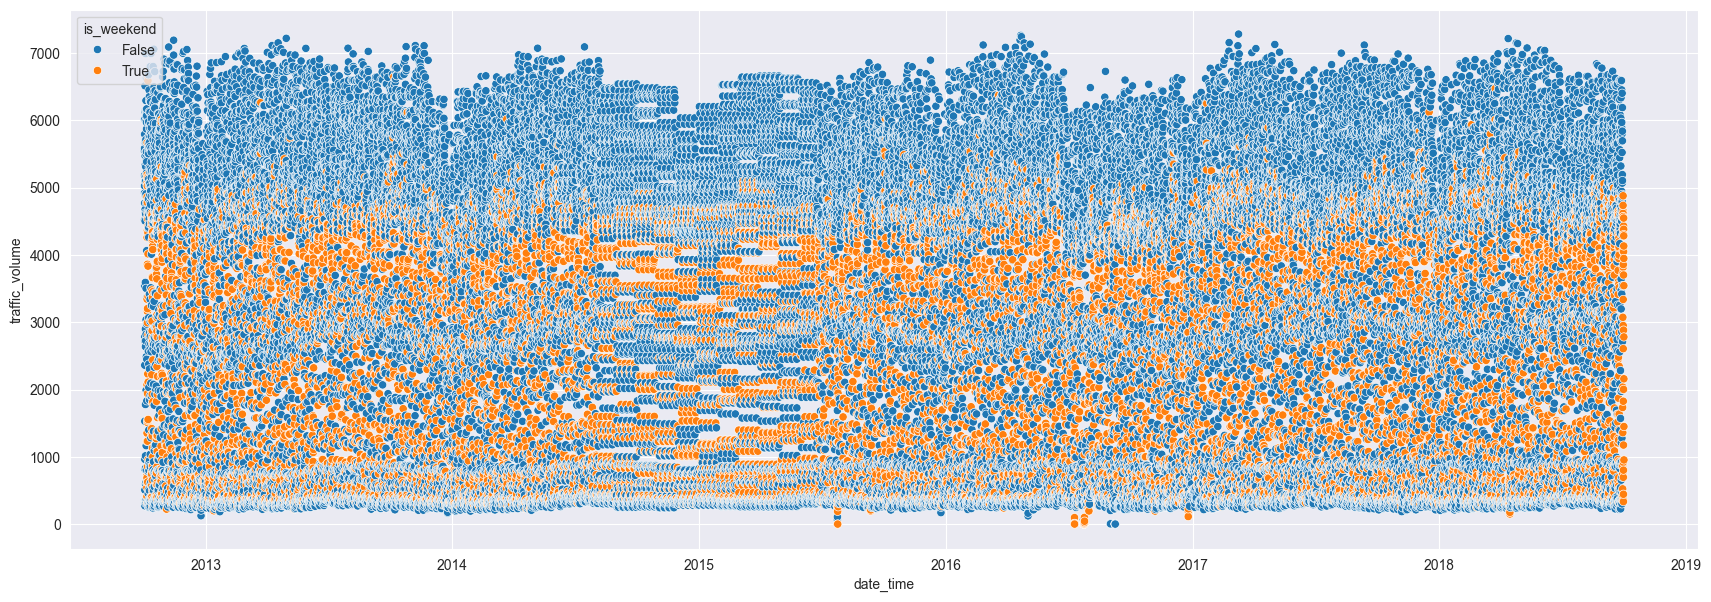

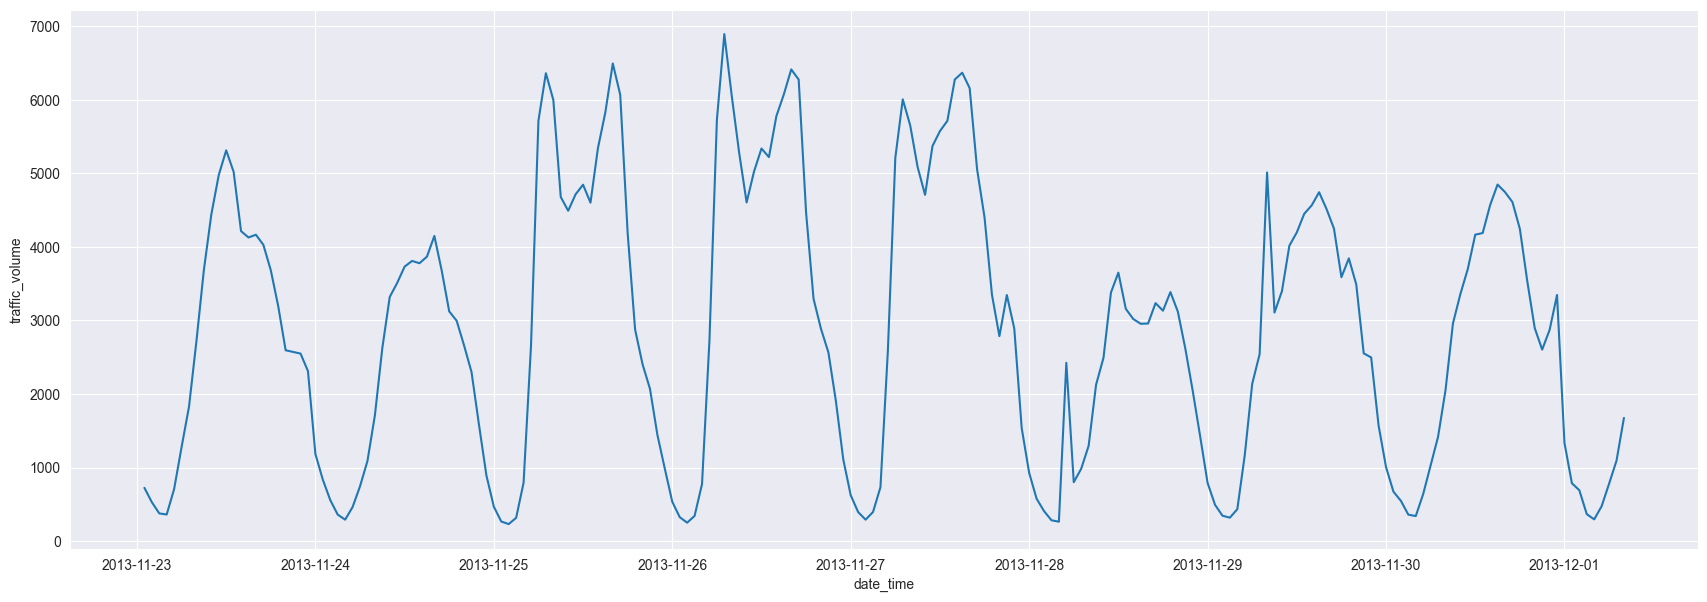

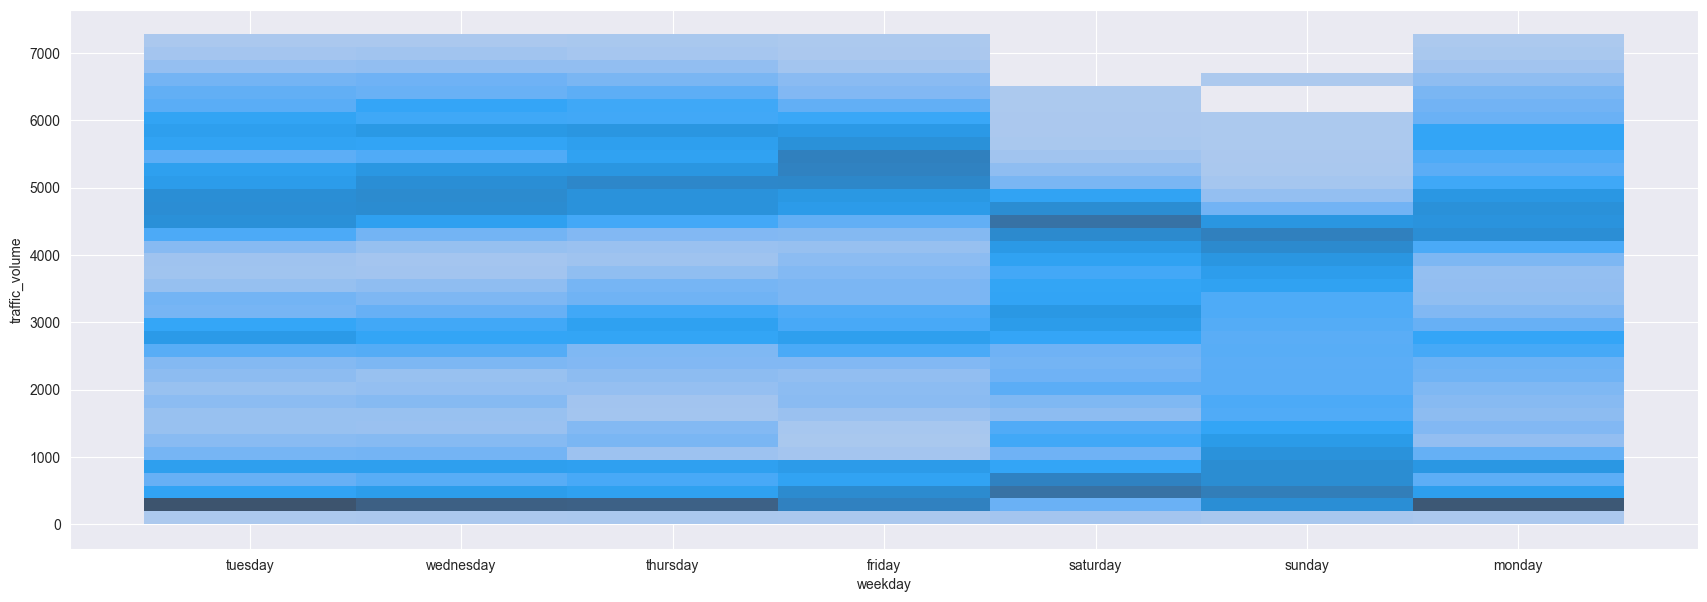

In [5]:
plt.figure(figsize=(21, 7))
sns.scatterplot(data, x="date_time", y="traffic_volume", hue="is_weekend")
plt.show()
plt.figure(figsize=(21, 7))
sns.lineplot(data[10000:10200], x="date_time", y="traffic_volume")
plt.show()
plt.figure(figsize=(21, 7))
sns.histplot(data, x="weekday", y="traffic_volume")
plt.show()

# Температурный график

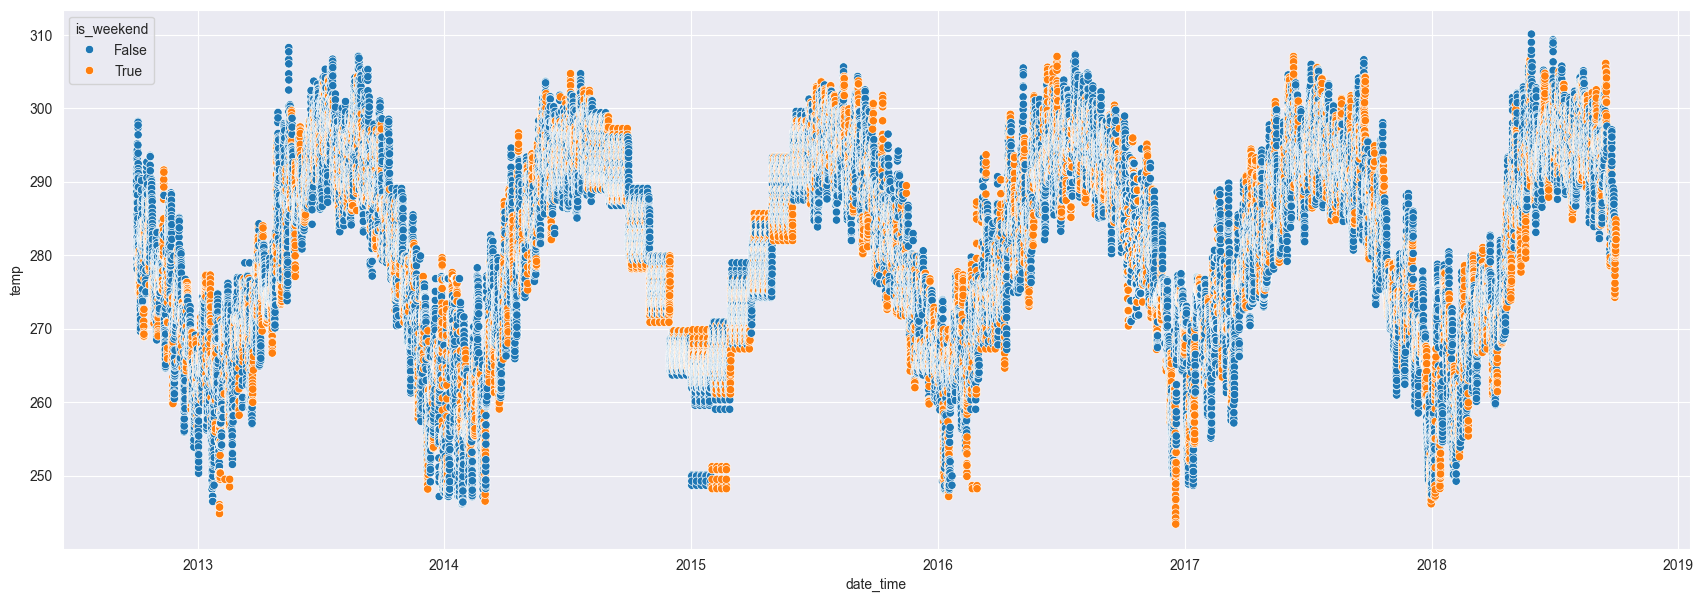

In [6]:
plt.figure(figsize=(21, 7))
sns.scatterplot(data, x="date_time", y="temp", hue="is_weekend")
plt.show()

# PairPlot

<Figure size 2100x700 with 0 Axes>

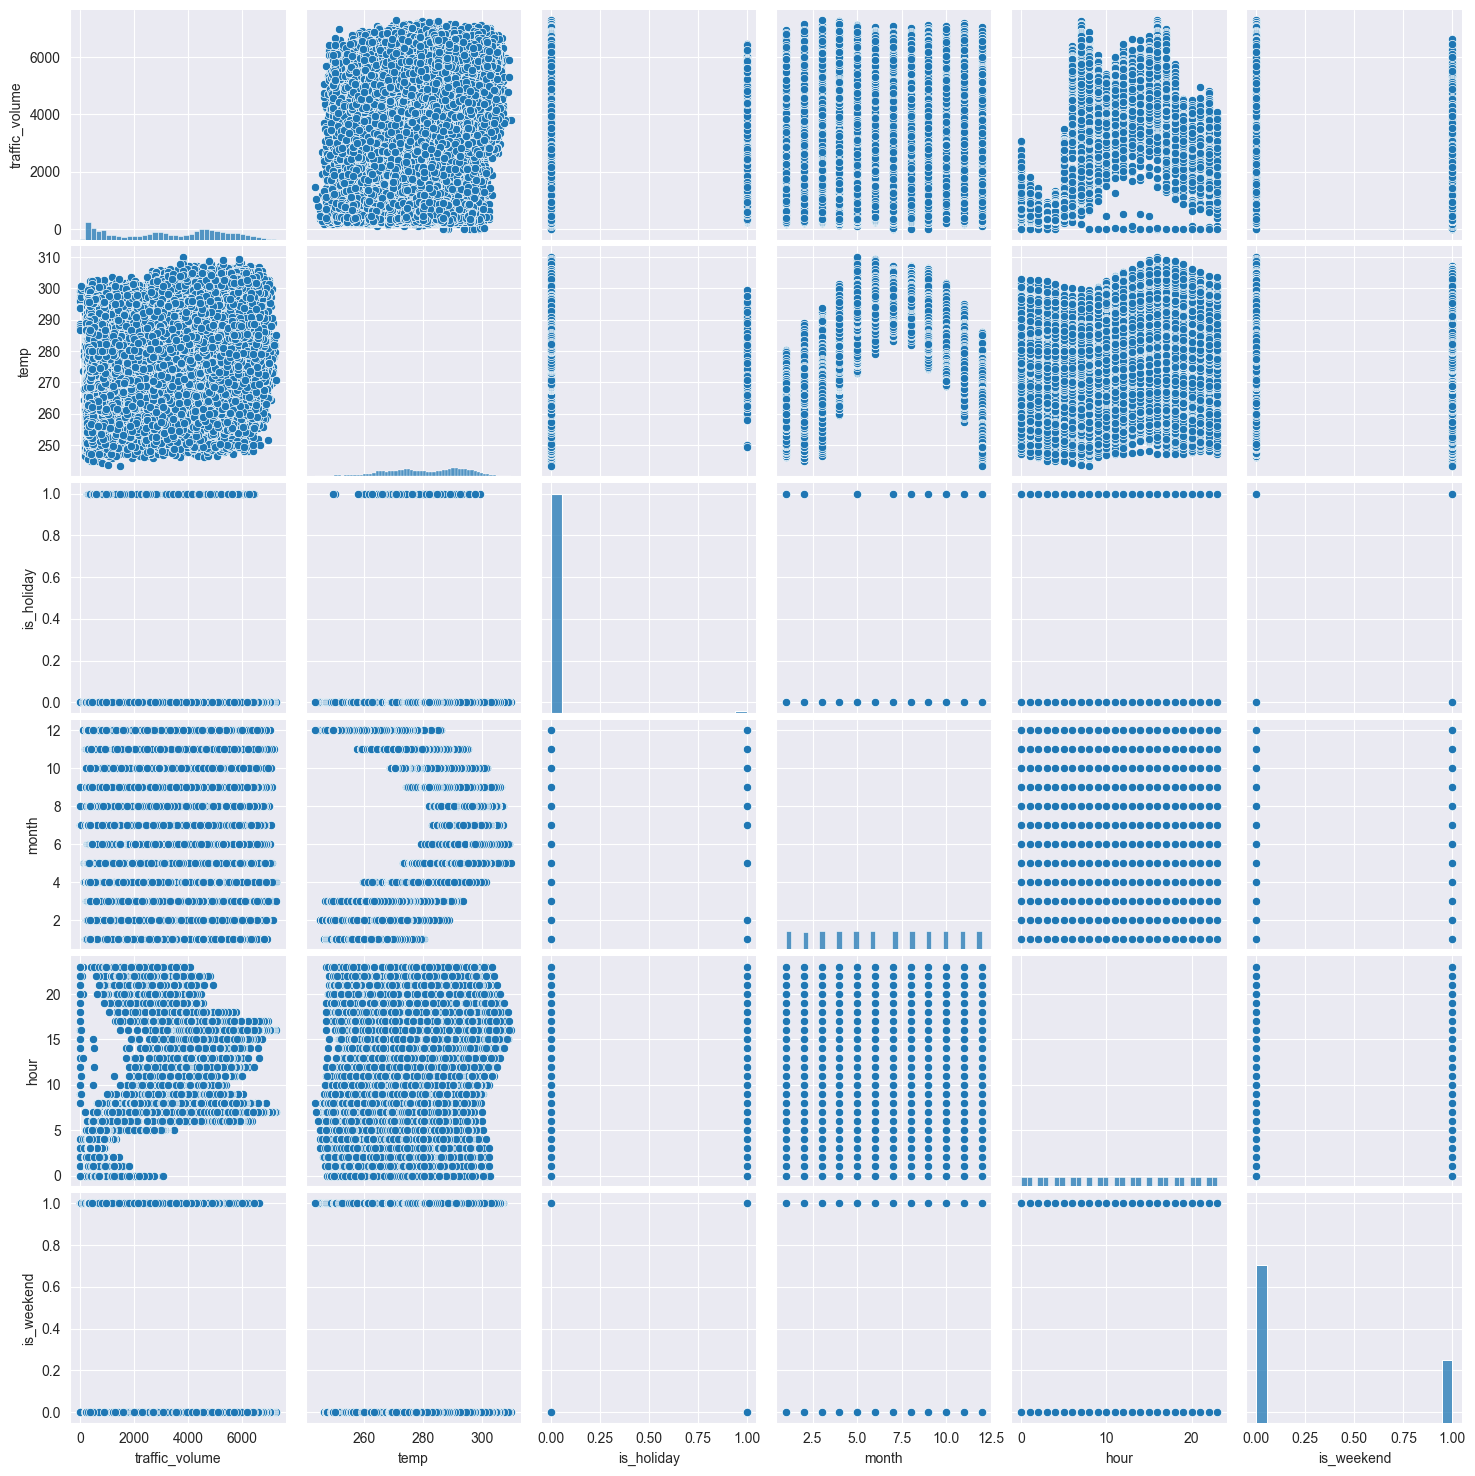

In [7]:
plt.figure(figsize=(21, 7))
sns.pairplot(data)

# Тест Дики-Фуллера

In [15]:
result = adfuller(data["traffic_volume"], autolag='AIC')
# lags = 10
# result = adfuller(data["traffic_volume"], maxlag=lags)
adf_statistic, p_value, usedlag, nobs, critical_values, icbest = result
lags = usedlag
print(f'ADF Статистика: {adf_statistic:.6f}')
print(f'p-value: {p_value:.6f}')
print(f'Использовано лагов: {usedlag}')
print(f'Количество наблюдений: {nobs}')
print(f'ICbest: {icbest}')
print('Критические значения:')
for key, value in critical_values.items():
    print(f'\t{key}: {value:.3f}')

ADF Статистика: -34.557303
p-value: 0.000000
Использовано лагов: 58
Количество наблюдений: 52492
ICbest: 786858.1500942276
Критические значения:
	1%: -3.430
	5%: -2.862
	10%: -2.567


In [16]:
result = adfuller(data["temp"], autolag='AIC')
# temp_lags = 57
# result = adfuller(data["temp"], maxlag=temp_lags)
adf_statistic, p_value, usedlag, nobs, critical_values, icbest = result
temp_lags = usedlag
print(f'ADF Статистика: {adf_statistic:.6f}')
print(f'p-value: {p_value:.6f}')
print(f'Использовано лагов: {usedlag}')
print(f'Количество наблюдений: {nobs}')
print(f'ICbest: {icbest}')
print('Критические значения:')
for key, value in critical_values.items():
    print(f'\t{key}: {value:.3f}')

ADF Статистика: -6.039010
p-value: 0.000000
Использовано лагов: 57
Количество наблюдений: 52493
ICbest: 213109.43298568224
Критические значения:
	1%: -3.430
	5%: -2.862
	10%: -2.567


# ACF / PACF

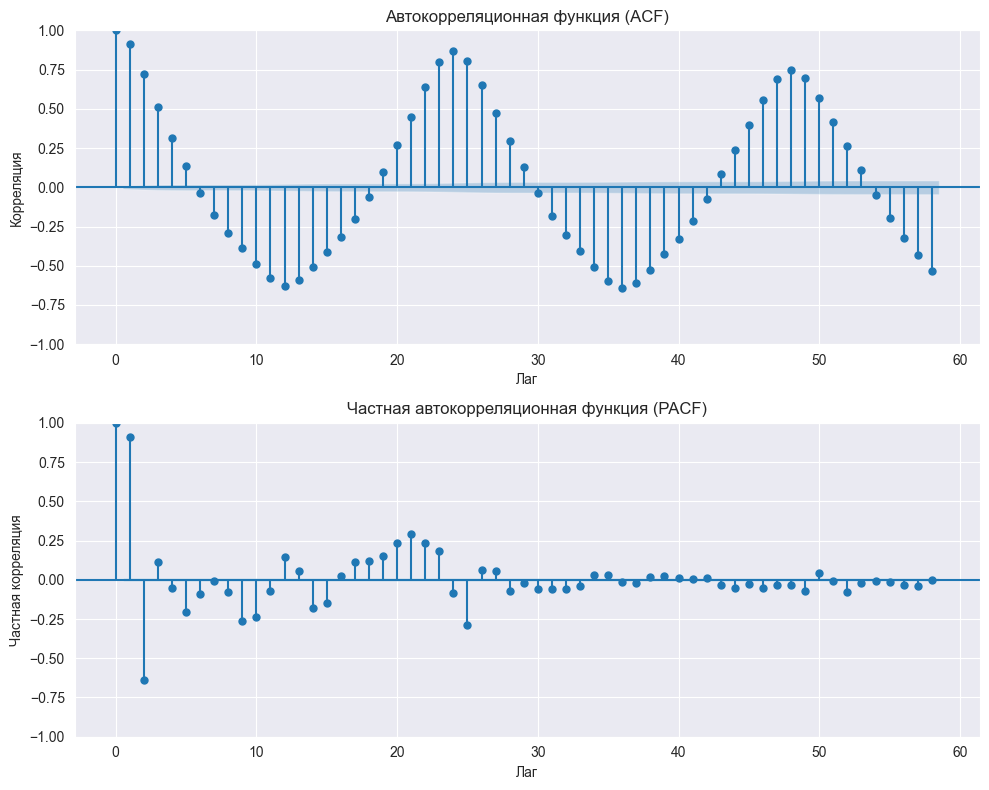

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ACF
plot_acf(data["traffic_volume"], ax=ax1, lags=lags, alpha=0.05)
ax1.set_title('Автокорреляционная функция (ACF)')
ax1.set_xlabel('Лаг')
ax1.set_ylabel('Корреляция')

# PACF
plot_pacf(data["traffic_volume"], ax=ax2, lags=lags, alpha=0.05, method='ywm')
ax2.set_title('Частная автокорреляционная функция (PACF)')
ax2.set_xlabel('Лаг')
ax2.set_ylabel('Частная корреляция')

plt.tight_layout()
plt.show()

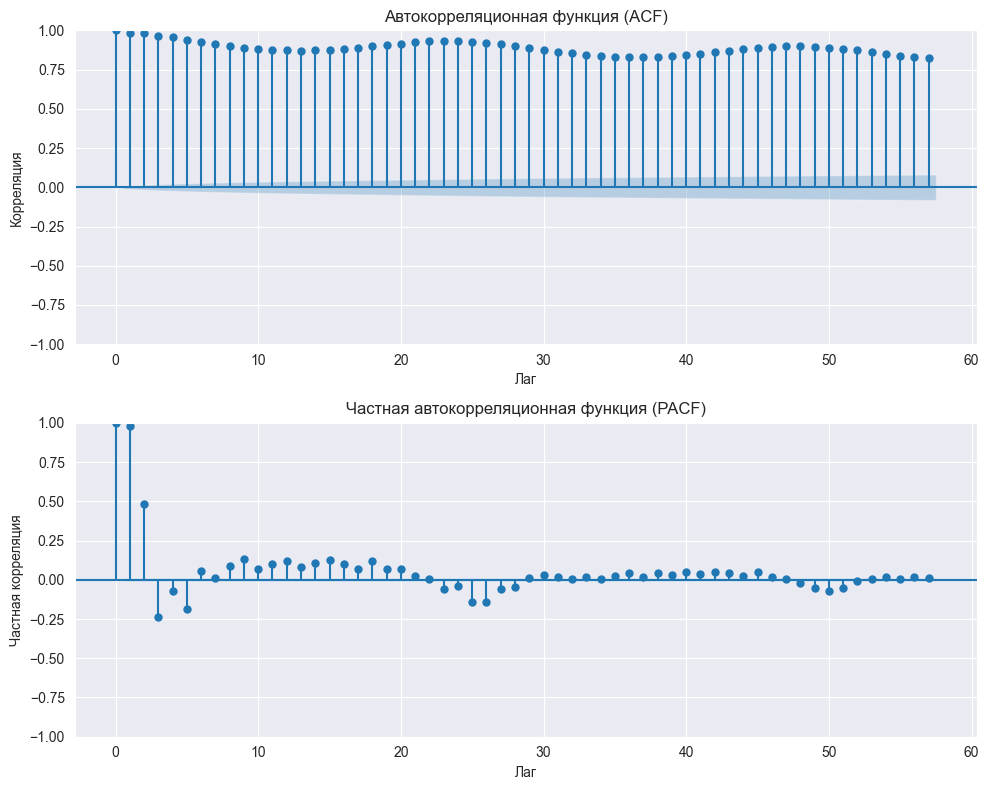

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ACF
plot_acf(data["temp"], ax=ax1, lags=temp_lags, alpha=0.05)
ax1.set_title('Автокорреляционная функция (ACF)')
ax1.set_xlabel('Лаг')
ax1.set_ylabel('Корреляция')

# PACF
plot_pacf(data["temp"], ax=ax2, lags=temp_lags, alpha=0.05, method='ywm')
ax2.set_title('Частная автокорреляционная функция (PACF)')
ax2.set_xlabel('Лаг')
ax2.set_ylabel('Частная корреляция')

plt.tight_layout()
plt.show()

# Разложение временного ряда

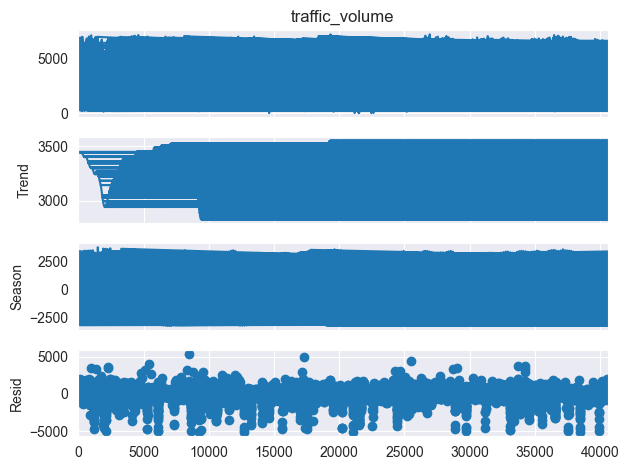

In [12]:
# STL декомпозиция (более устойчива к выбросам)
stl = STL(data["traffic_volume"], period=24 * 7, robust=True)
result_stl = stl.fit()

# Визуализация
fig = result_stl.plot()
plt.show()

In [3]:
def plot_data(data, ax=None, y_col="traffic_volume"):
    if not ax:
        plt.figure(figsize=(21, 7))

    title = f"{data["date_time"].iloc[0]} - {data["date_time"].iloc[-1]} : {len(data)}"
    if ax:
        ax.set_title(title)
    else:
        plt.title(title)
    sns.scatterplot(data, x="date_time", y=y_col, hue="is_weekend", ax=ax)
    if not ax:
        plt.show()


def plot_preds(y_true, y_pred, x, prediction_type=None):
    fig, ax = plt.subplots(figsize=(21, 7))

    plt.title(f"MSE: {mean_squared_error(y_true, y_pred):,.2f}. Тип предсказаний: {prediction_type}")
    sns.lineplot(y=y_true, x=x, label='Истинные значения', ax=ax)
    sns.lineplot(y=y_pred, x=x, label='Предсказанные значения', ax=ax)

    plt.show()


def folded_plot(data, splits, splits_len=5):
    fig, axes = plt.subplots(splits_len, 2, figsize=(21, 7))
    fig.tight_layout(pad=3)
    for i, (train_index, test_index) in enumerate(splits):
        train_fold = data.iloc[train_index]
        train_ax = axes[i][0]
        plot_data(train_fold, train_ax)

        test_fold = data.iloc[test_index]
        test_ax = axes[i][1]
        plot_data(test_fold, test_ax)
    plt.show()


def get_splitted_data(data, exec_weeks=2, train_weeks=4, splits=5):
    # Все данные разбиты с шагом в час
    # Это означает что последние две недели это x часов, а значит нам надо x последних записей
    records = lambda weeks: (24 * 7 * weeks)

    exec_data = data[-records(exec_weeks):]
    test_data = data[:-records(exec_weeks)]
    print("Разница между первой и последней записями в финальном датасете:",
          exec_data.iloc[-1]["date_time"] - exec_data.iloc[0]["date_time"])

    test_data = test_data[-records(train_weeks):]
    return exec_data, test_data, TimeSeriesSplit(n_splits=splits).split(test_data), splits

# Распределение тестовой выборки и фолдов

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00


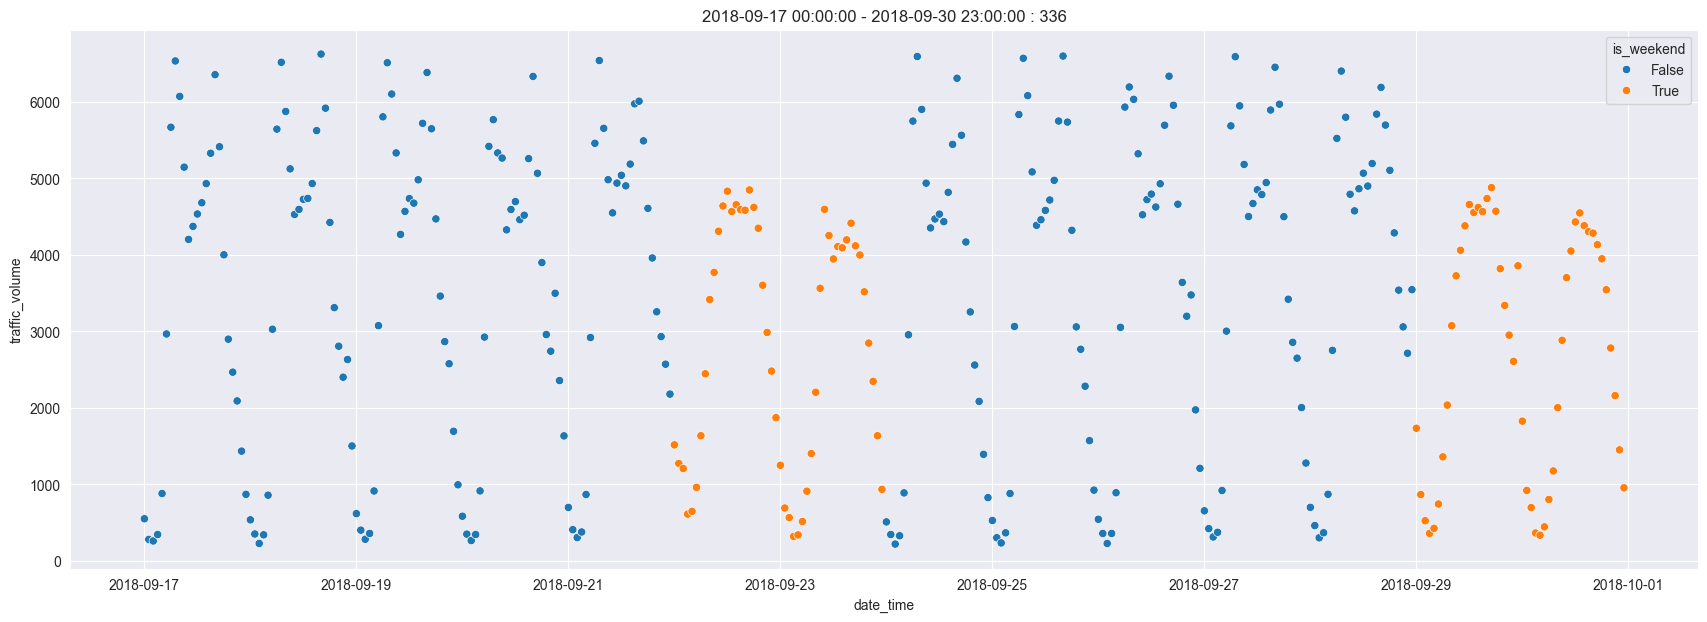

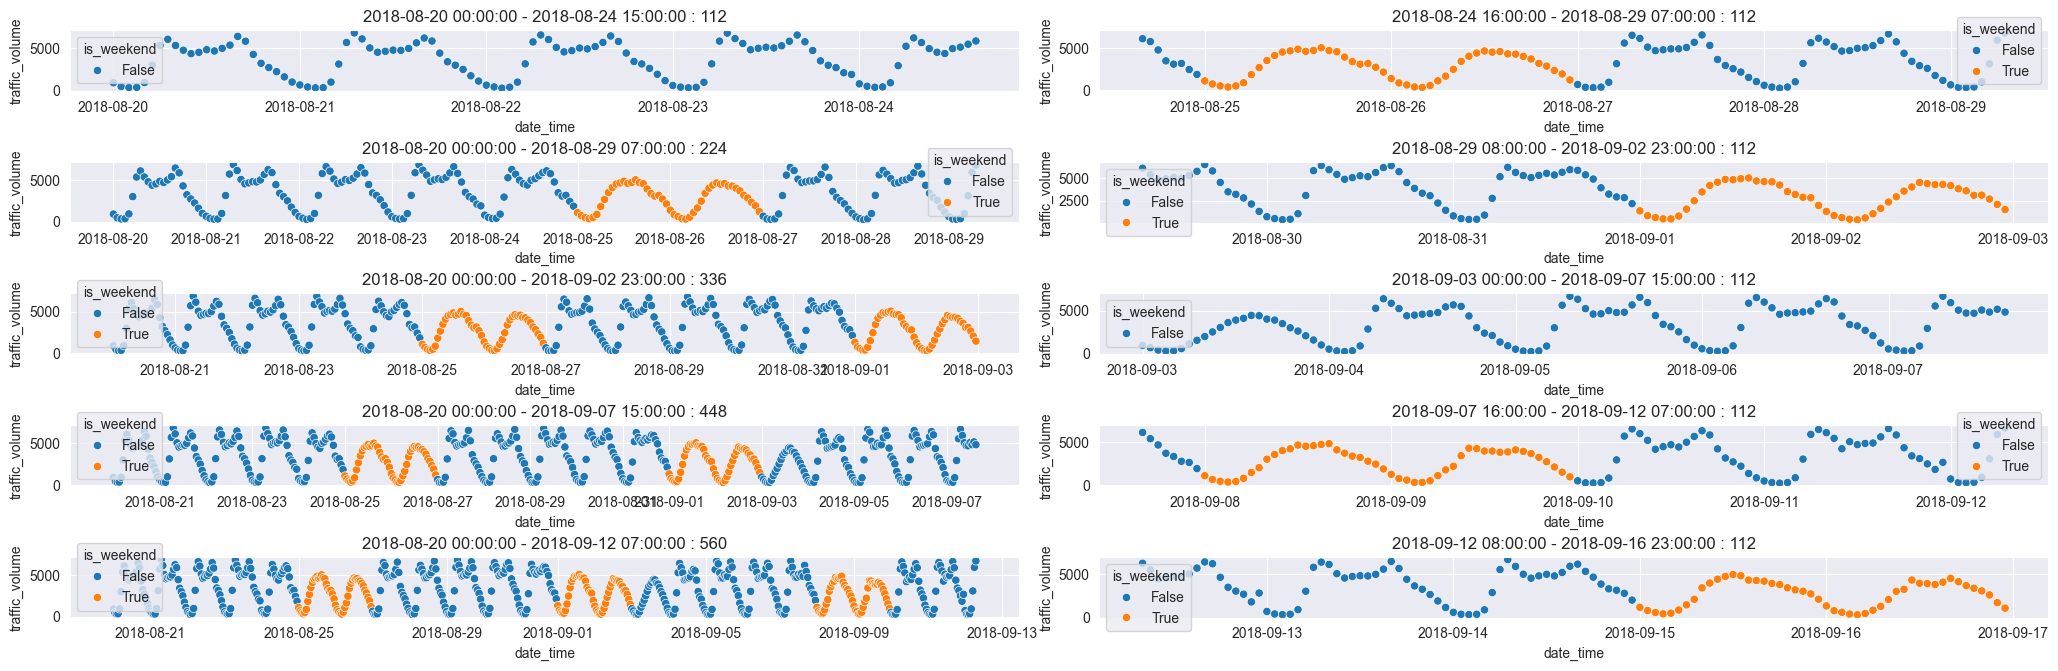

In [4]:
exec_data, train_data, train_splits, splits = get_splitted_data(data)
plot_data(exec_data)
folded_plot(train_data, train_splits, splits)

# Baseline по среднему значению

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00
108601.90710780697


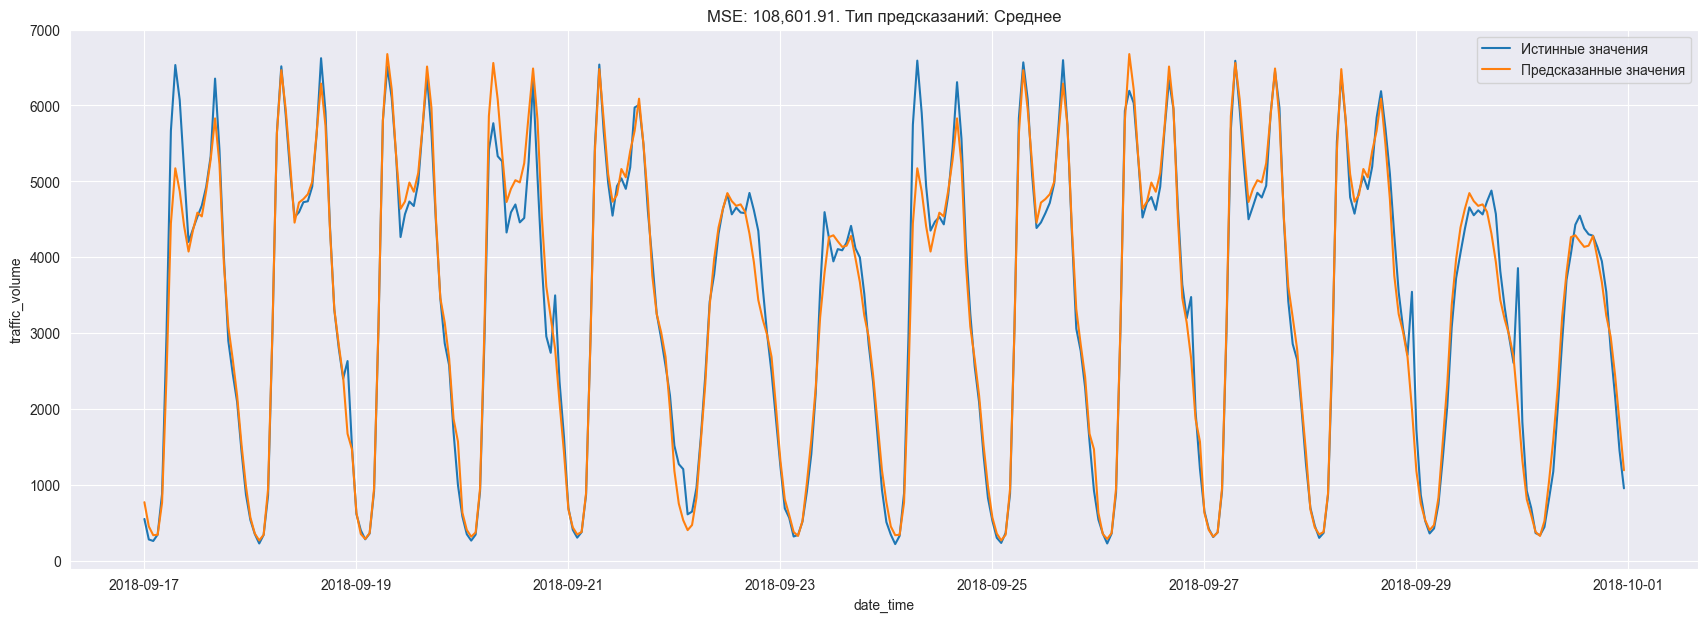

In [18]:
exec_data, train_data, train_splits, splits = get_splitted_data(data)
help_df: pd.DataFrame = train_data.copy()
help_df = help_df[["traffic_volume", "weekday", "hour"]]
help_df = help_df.groupby(by=["weekday", "hour"]).mean().reset_index()


def find_value(x):
    hour = help_df["hour"] == x["date_time"].hour
    weekday = help_df["weekday"] == x["weekday"]
    return help_df[(hour & weekday)]["traffic_volume"].iloc[0]


y_true = exec_data["traffic_volume"]
y_pred = exec_data.apply(find_value, axis=1)

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true, y_pred, exec_data["date_time"], "Среднее")

# ARIMA

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00
130797.40181095233


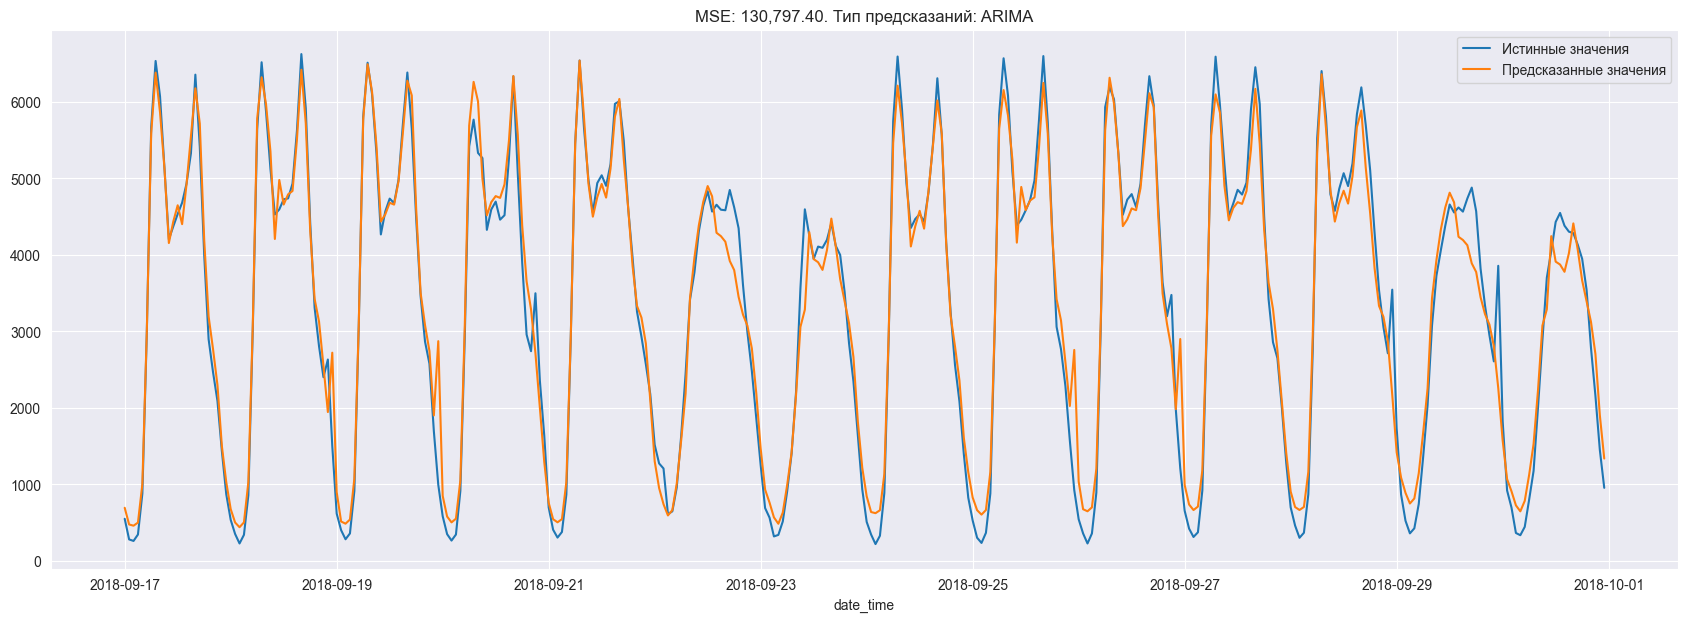

In [53]:
exec_data, train_data, train_splits, splits = get_splitted_data(data, train_weeks=4)

arima = ARIMA(train_data["traffic_volume"], seasonal_order=(1, 0, 0, 24 * 7)).fit()

y_true = exec_data["traffic_volume"]
y_pred = arima.predict(start=len(train_data), end=len(train_data) + len(exec_data) - 1, dynamic=False)

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true.tolist(), y_pred.tolist(), exec_data["date_time"], "ARIMA")

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00
3993847.211940252
56722.57185433259
882835.1801546924
896745.421766135
98081.0320738497
10597095.961966613


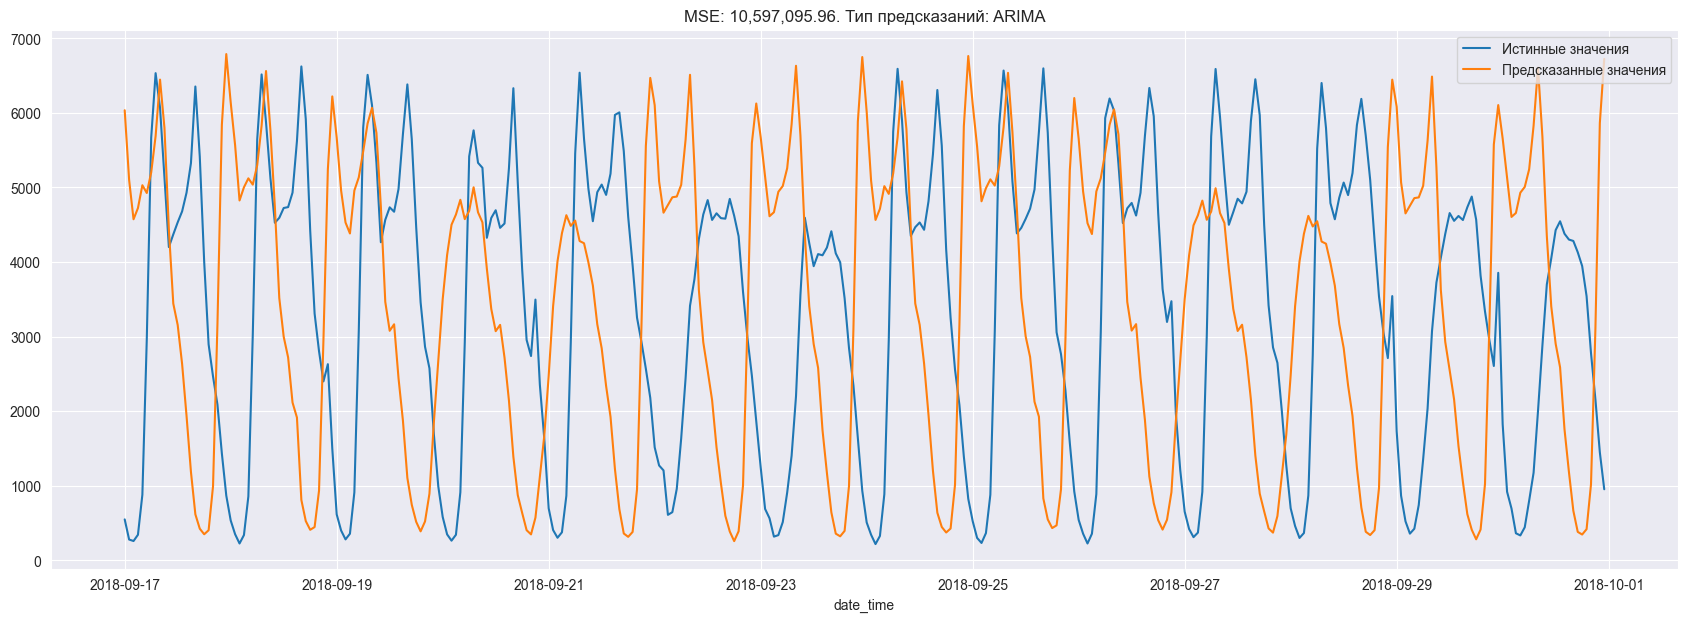

In [52]:
exec_data, train_data, train_splits, splits = get_splitted_data(data, train_weeks=4)

arima = ARIMA(train_data["traffic_volume"], seasonal_order=(1, 0, 0, 24 * 7)).fit()

best_model = None
best_model_mse = float("inf")
for i, (train_index, test_index) in enumerate(train_splits):
    train_fold = train_data.iloc[train_index]
    test_fold = train_data.iloc[test_index]

    arima = ARIMA(train_fold["traffic_volume"], seasonal_order=(1, 0, 0, 24 * 7)).fit()

    y_true = test_fold["traffic_volume"]
    y_pred = arima.predict(start=len(train_fold), end=len(train_fold) + len(test_fold) - 1, dynamic=False)

    mse = mean_squared_error(y_true, y_pred)
    print(mse)
    if mse < best_model_mse:
        best_model_mse = mse
        best_model = arima
        best_model_length = len(train_fold)

    # plot_preds(y_true.tolist(), y_pred.tolist(), test_fold["date_time"], "ARIMA")

y_true = exec_data["traffic_volume"]
y_pred = best_model.predict(start=best_model_length, end=best_model_length + len(exec_data) - 1, dynamic=False)

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true.tolist(), y_pred.tolist(), exec_data["date_time"], "ARIMA")

In [15]:
exec_data, train_data, train_splits, splits = get_splitted_data(data, train_weeks=4, exec_weeks=2)

sf = StatsForecast(models=[nixtla.ARIMA(seasonal_order=(1, 0, 0), season_length=24 * 7)], freq="YS")

train_data["unique_id"] = 1
train_data["ds"] = pd.to_datetime(train_data["date_time"])
train_data["y"] = train_data["traffic_volume"]

y_true = exec_data["traffic_volume"]
y_pred = sf.forecast(df=train_data[["ds", "y", "unique_id"]], h=len(y_true))["AutoARIMA"]

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true.tolist(), y_pred.tolist(), exec_data["date_time"], "AutoARIMA")

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00


OverflowError: Overflow occurred in npy_datetimestruct_to_datetime

# RandomForest

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00
1162630.1585964698
70427.73182128262
797896.1525111657
678671.7938128462
72121.84140420156
103910.03600164232


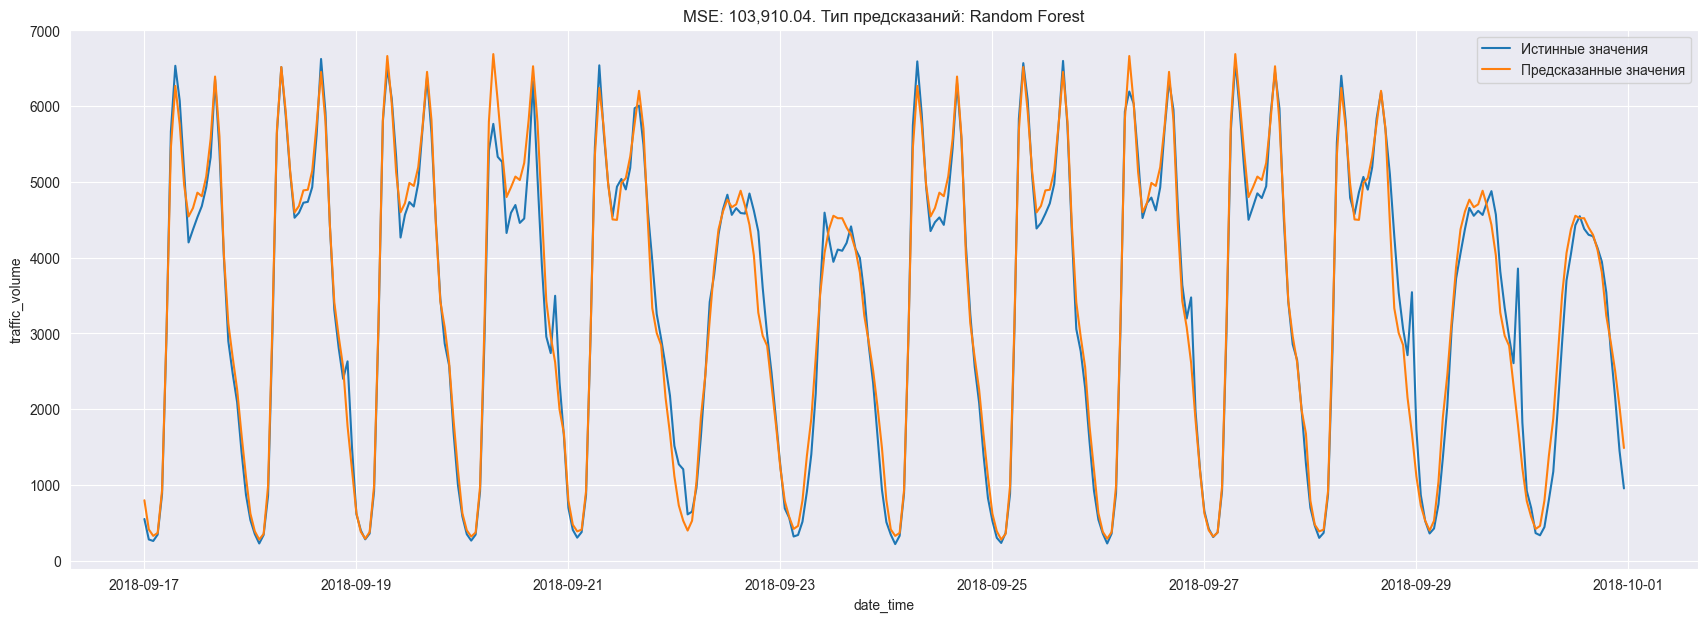

In [56]:
exec_data, train_data, train_splits, splits = get_splitted_data(data)

columns = ["holiday", "weekday", "month"]

encoder = OrdinalEncoder().fit(data[columns])


def preprocess_data(data):
    transformed = encoder.transform(data[columns])
    transformed_df = pd.DataFrame(transformed, index=data.index, columns=[col + "_enc" for col in columns])
    data = pd.concat([data, transformed_df], axis=1, ignore_index=False)
    data.drop(columns, axis=1, inplace=True)

    return data


best_model = None
best_model_mse = float("inf")
for i, (train_index, test_index) in enumerate(train_splits):
    train_fold = train_data.iloc[train_index]
    test_fold = train_data.iloc[test_index]

    model = RandomForestRegressor(n_estimators=500, n_jobs=-1, criterion="squared_error", random_state=42)
    model.fit(preprocess_data(train_fold.drop(["traffic_volume", "date_time", "temp"], axis=1)),
              train_fold["traffic_volume"])

    y_true = test_fold["traffic_volume"]
    y_pred = model.predict(preprocess_data(test_fold.drop(["traffic_volume", "date_time", "temp"], axis=1)))

    mse = mean_squared_error(y_true, y_pred)
    print(mse)
    if mse < best_model_mse:
        best_model_mse = mse
        best_model = model

    # plot_preds(y_true, y_pred, test_fold["date_time"], "Random Forest")

y_true = exec_data["traffic_volume"]
y_pred = best_model.predict(preprocess_data(exec_data.drop(["traffic_volume", "date_time", "temp"], axis=1)))

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true, y_pred, exec_data["date_time"], "Random Forest")

# Boosting

Разница между первой и последней записями в финальном датасете: 13 days 23:00:00
1175607.6166203443
53311.899563693485
765125.0355037616
659663.777057966
75441.48082904382
94084.35631099698


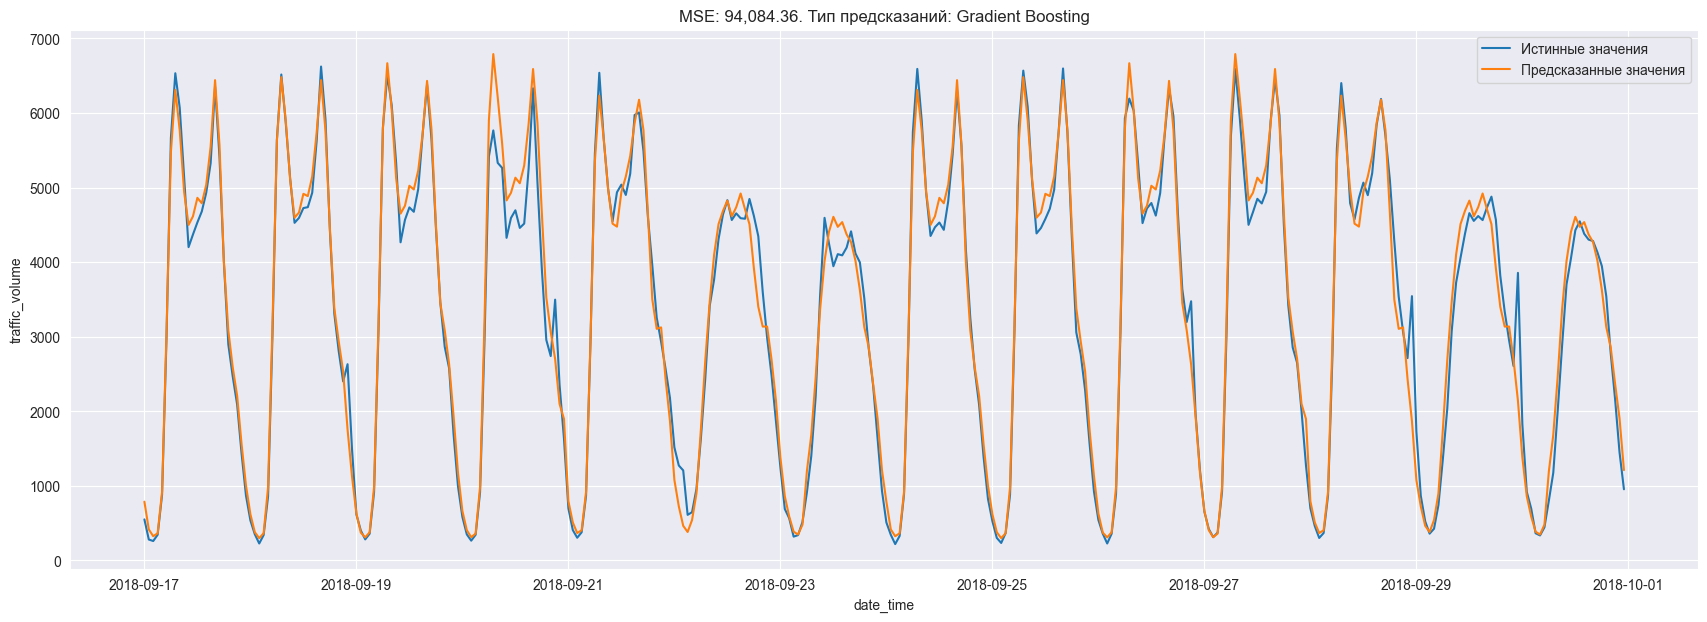

In [59]:
exec_data, train_data, train_splits, splits = get_splitted_data(data)

columns = ["holiday", "weekday", "month"]
encoder = OneHotEncoder(sparse_output=False).fit(data[columns])

best_model = None
best_model_mse = float("inf")


def preprocess_data(data, scaler):
    transformed = encoder.transform(data[columns])
    transformed_df = pd.DataFrame(transformed, index=data.index, columns=encoder.get_feature_names_out(columns))
    data = pd.concat([data, transformed_df], axis=1, ignore_index=False)

    data.drop(columns, axis=1, inplace=True)
    try:
        check_is_fitted(scaler)
    except NotFittedError as exc:
        scaler.fit(data)

    data = pd.DataFrame(scaler.transform(data), index=data.index, columns=data.columns)

    return data


for i, (train_index, test_index) in enumerate(train_splits):
    train_fold = train_data.iloc[train_index]
    test_fold = train_data.iloc[test_index]

    scaler = MinMaxScaler()

    model = GradientBoostingRegressor(n_estimators=500, criterion="squared_error", random_state=42)
    model.fit(preprocess_data(train_fold.drop(["traffic_volume", "date_time", "temp"], axis=1), scaler),
              train_fold["traffic_volume"])

    y_true = test_fold["traffic_volume"]
    y_pred = model.predict(preprocess_data(test_fold.drop(["traffic_volume", "date_time", "temp"], axis=1), scaler))

    mse = mean_squared_error(y_true, y_pred)
    print(mse)
    if mse < best_model_mse:
        best_model_mse = mse
        best_model = model
        best_scaler = scaler

    # plot_preds(y_true, y_pred, test_fold["date_time"], "Gradient Boosting")

y_true = exec_data["traffic_volume"]
y_pred = best_model.predict(preprocess_data(exec_data.drop(["traffic_volume", "date_time", "temp"], axis=1), best_scaler))

print(mean_squared_error(y_true, y_pred))

plot_preds(y_true, y_pred, exec_data["date_time"], "Gradient Boosting")